# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [167]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [172]:
mnase_analysis = MNaseOriginAnalysis()

In [522]:
replicate = 2
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

Replicate: 2, 10
chrom read timepoints: [  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]


In [630]:
mnase_analysis.compute_sliding_window_counts_all_times()

In [757]:
mnase_analysis.normalize_samples()

Text(0.5, 1.0, 'Normalized read counts, accounting for copy number')

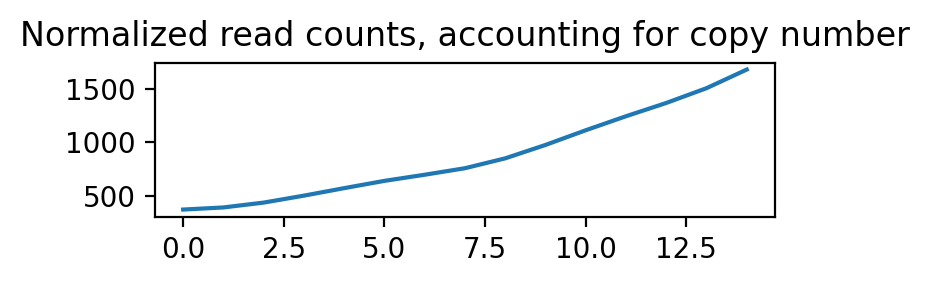

In [758]:
plt.figure(figsize=(4, 1))
plt.plot(mnase_analysis.sample_normalized.sum(axis=1))
plt.title("Normalized read counts, accounting for copy number")

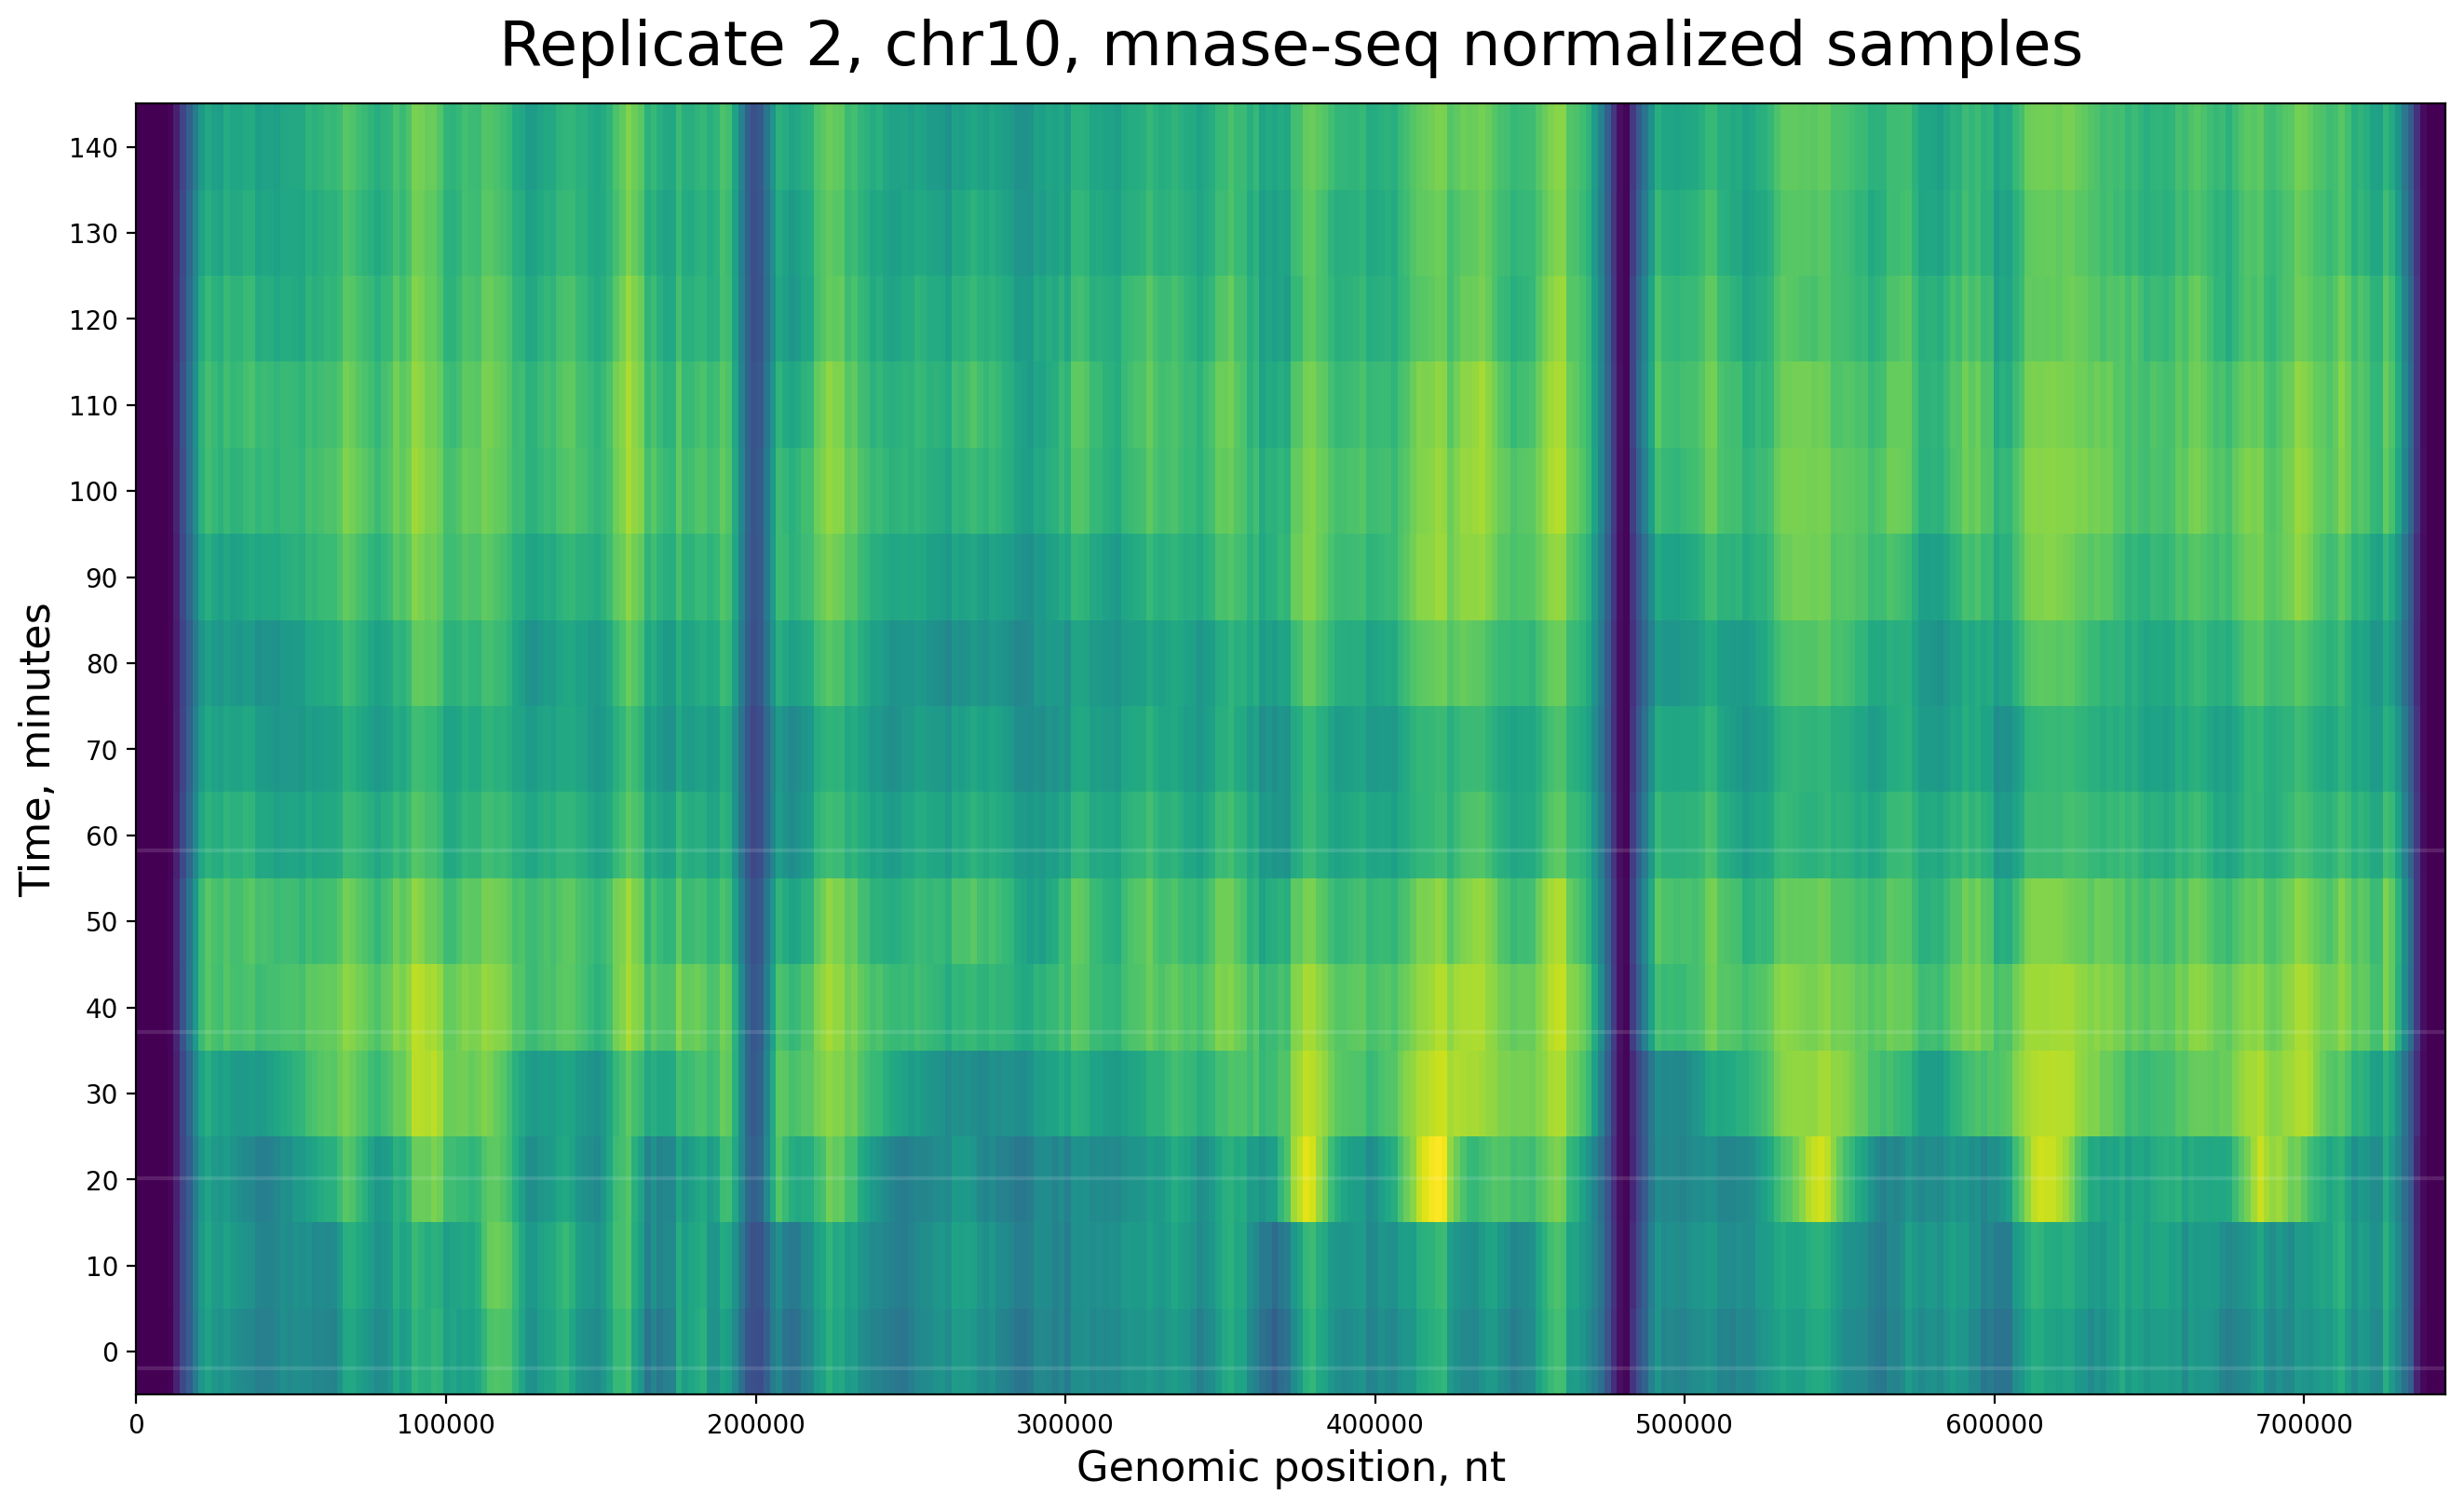

In [759]:
mnase_analysis.plot_heatmap()

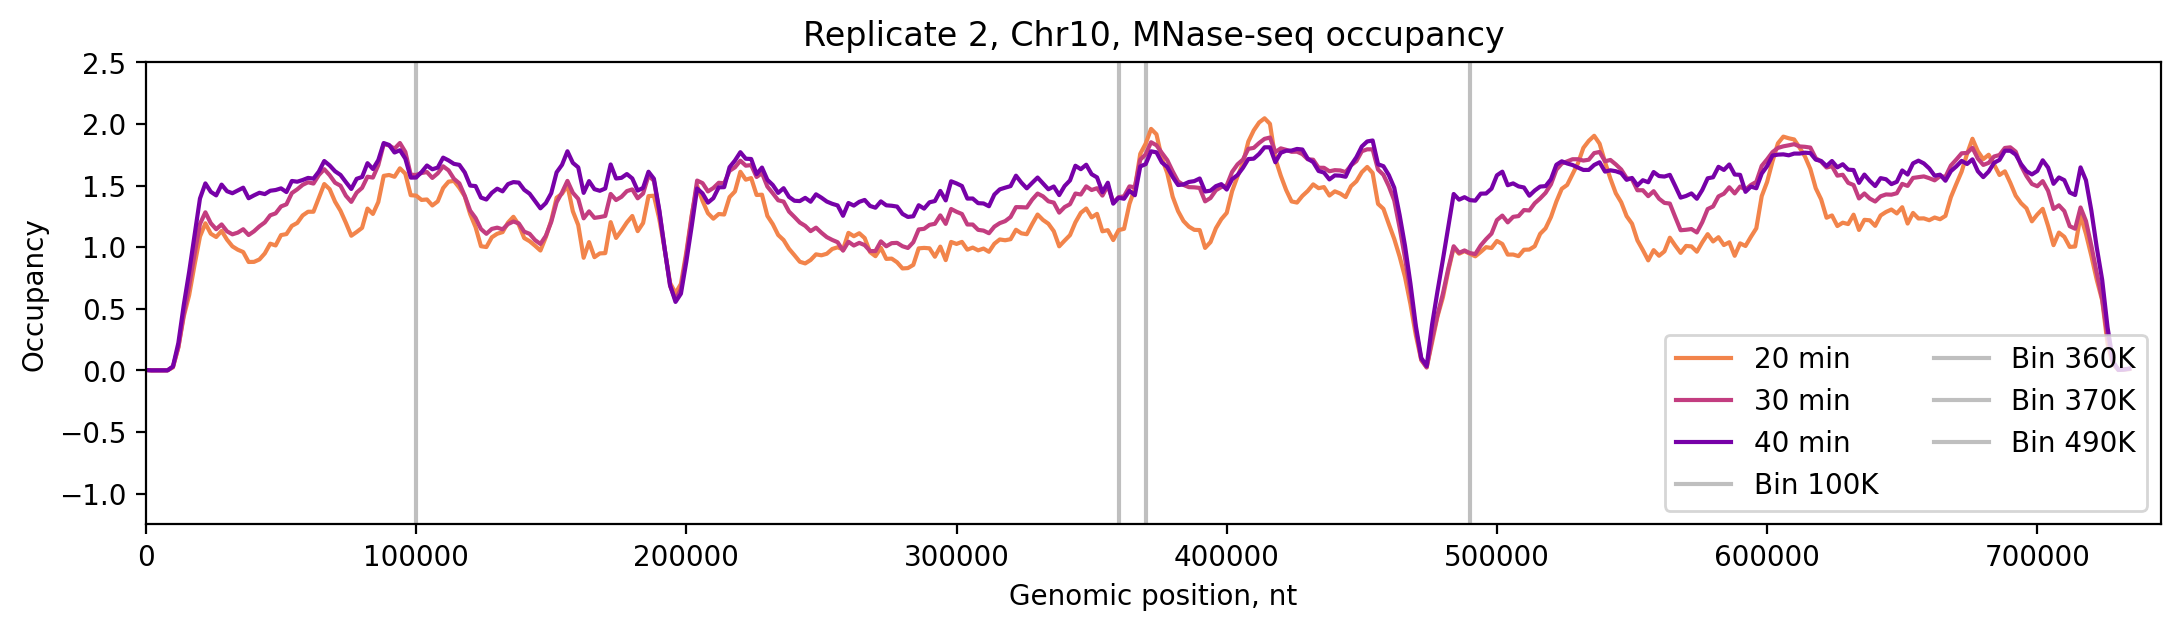

In [931]:
selected_bins=[50, 180, 185, 245]
time_indices=[2, 3, 4]
mnase_analysis.plot_bin_occupancy_for_selected_timepoints(time_indices, selected_bins)

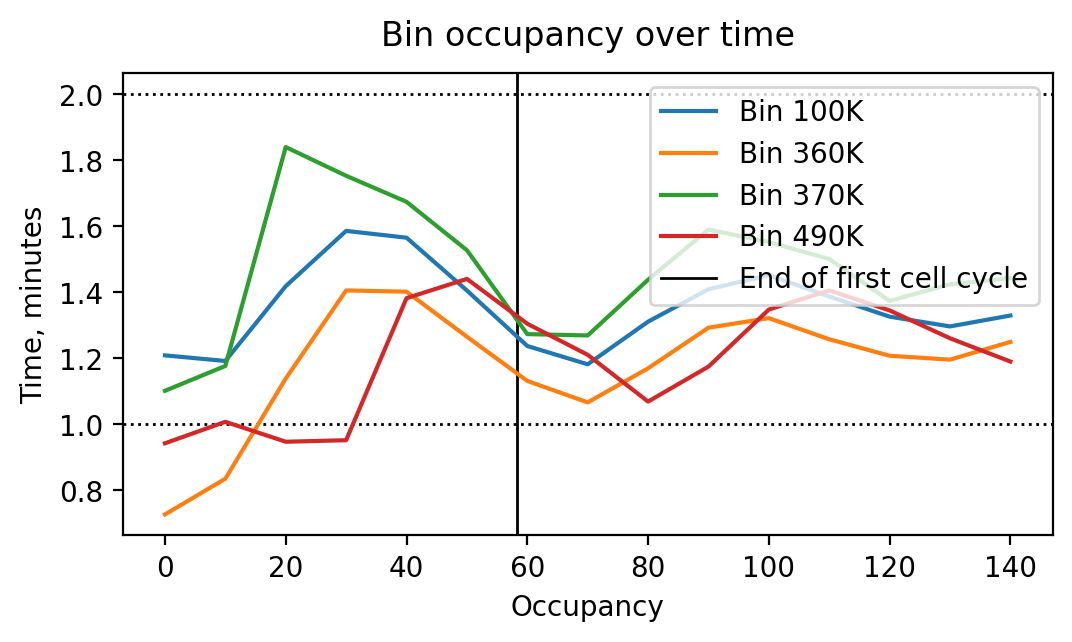

In [932]:
mnase_analysis.plot_selected_bin_occupancy(selected_bins)

In [966]:
mnase_analysis.get_replication_timing(thresh_prop=0.6)

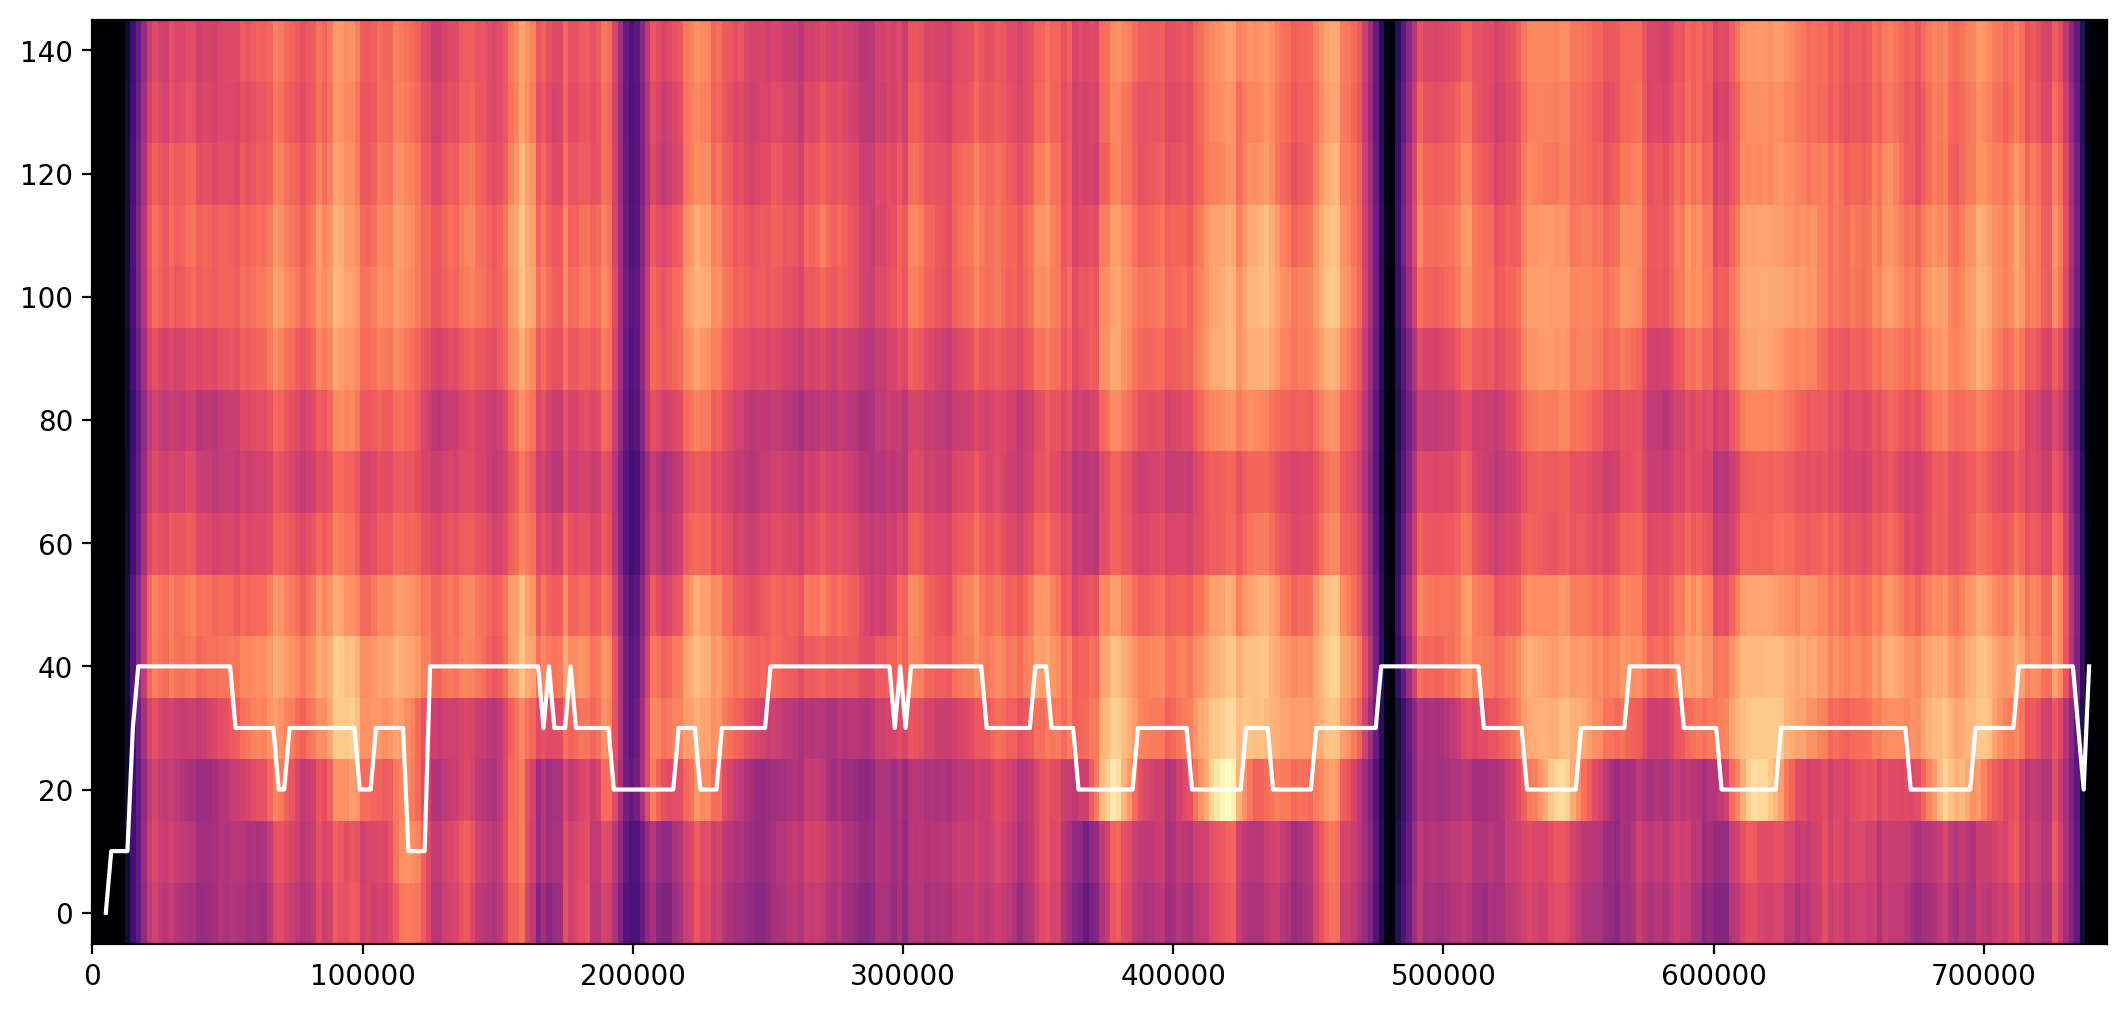

In [967]:
plt.figure(figsize=(13, 6))

plt.imshow(mnase_analysis.counts_normalized_by_copy, origin='lower', aspect='auto',
           cmap='magma',
           extent=[0, mnase_analysis.chrom_len,
                  -5, mnase_analysis.timepoints[-1]+5])
plt.plot(mnase_analysis.start_indices+mnase_analysis.window_size/2., 
    mnase_analysis.replication_timepoints, c='white')


In [968]:
second_cell_cycle_tps = mnase_analysis.timepoints[mnase_analysis.timepoints > 60] 
mnase_analysis.get_replication_timing(thresh_prop=0.6, sel_timepoints=second_cell_cycle_tps)

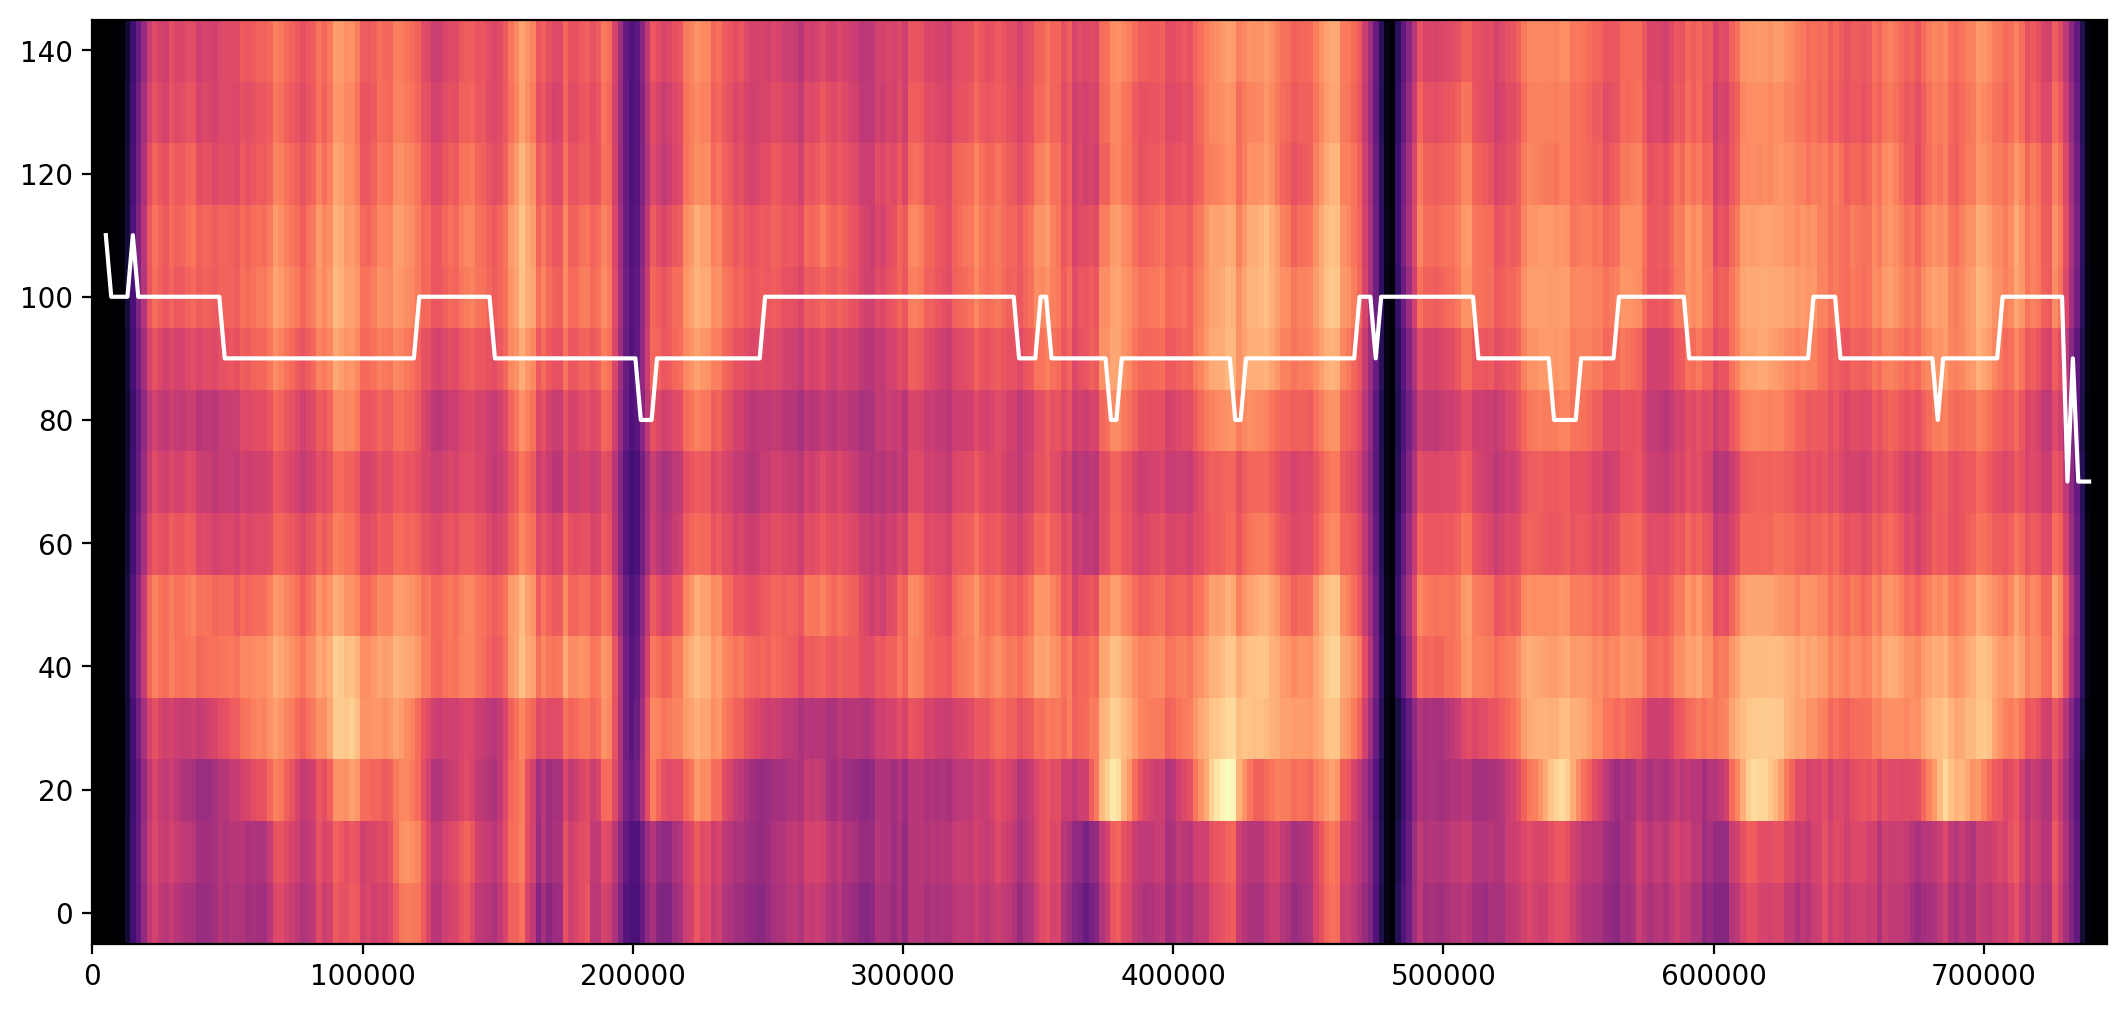

In [969]:
plt.figure(figsize=(13, 6))

plt.imshow(mnase_analysis.counts_normalized_by_copy, origin='lower', aspect='auto',
           cmap='magma',
           extent=[0, mnase_analysis.chrom_len,
                  -5, mnase_analysis.timepoints[-1]+5])
plt.plot(mnase_analysis.start_indices+mnase_analysis.window_size/2., 
    mnase_analysis.replication_timepoints, c='white')
